# Hedging - Volatility Mismatch

In [125]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
from math import erf

## 1. Matching Volatility 

We firstly validate our GBM approach and then implement the delta hedge via Black-Scholes

In [126]:
def option_step(S, r, sigma, dt, rng):
    """Calculates one Euler-Maruyama step of the option price"""
    Z = rng.standard_normal()
    return S + r*S*dt + sigma*S*Z*np.sqrt(dt)

def validate_option_step():
    """Validates the option_step function by simulating multiple paths and plotting the results"""
    S0 = 100
    r = 0.06
    sigma = 0.2
    T = 1
    dt = 0.01
    N = int(T/dt)
    rng = np.random.default_rng(seed=42)
    its = 1000
    # Simulate multiple paths
    paths = np.zeros((N, its))
    for i in range(its):
        S = S0
        for t in range(N):
            S = option_step(S, r, sigma, dt, rng)
            paths[t, i] = S

    # Theory
    time_grid = np.linspace(0, T, N)
    theoretical_mean = S0 * np.exp(r * time_grid)
    theoretical_std = S0 * np.exp(r * time_grid) * sigma * np.sqrt(time_grid)

    # Plot the results
    plt.figure(figsize=(10, 6), dpi=300)
    plt.plot(np.linspace(0, T, N), paths, alpha=0.2)
    plt.plot(np.linspace(0, T, N), paths.mean(axis=1), label='Simulated Mean')
    plt.plot(np.linspace(0, T, N), theoretical_mean, label='Theoretical Mean', color="black")
    plt.plot(np.linspace(0, T, N), theoretical_mean + theoretical_std, color='black', ls='--')
    plt.plot(np.linspace(0, T, N), theoretical_mean - theoretical_std, color='black', ls='--')
    plt.title(f'Theory v Sim N={its}')
    plt.legend()
    plt.xlabel('Time (years)')
    plt.ylabel('Option Price')
    plt.grid()
    #plt.show()

    print(f"Theory\t {theoretical_mean[-1]:.2f} ± {theoretical_std[-1]:.2f}")
    print(f"Sim\t {paths[-1].mean():.2f} ± {paths[-1].std():.2f}") 
    print(f"N = {its}")


Theory	 106.18 ± 21.24
Sim	 105.42 ± 22.21
N = 1000


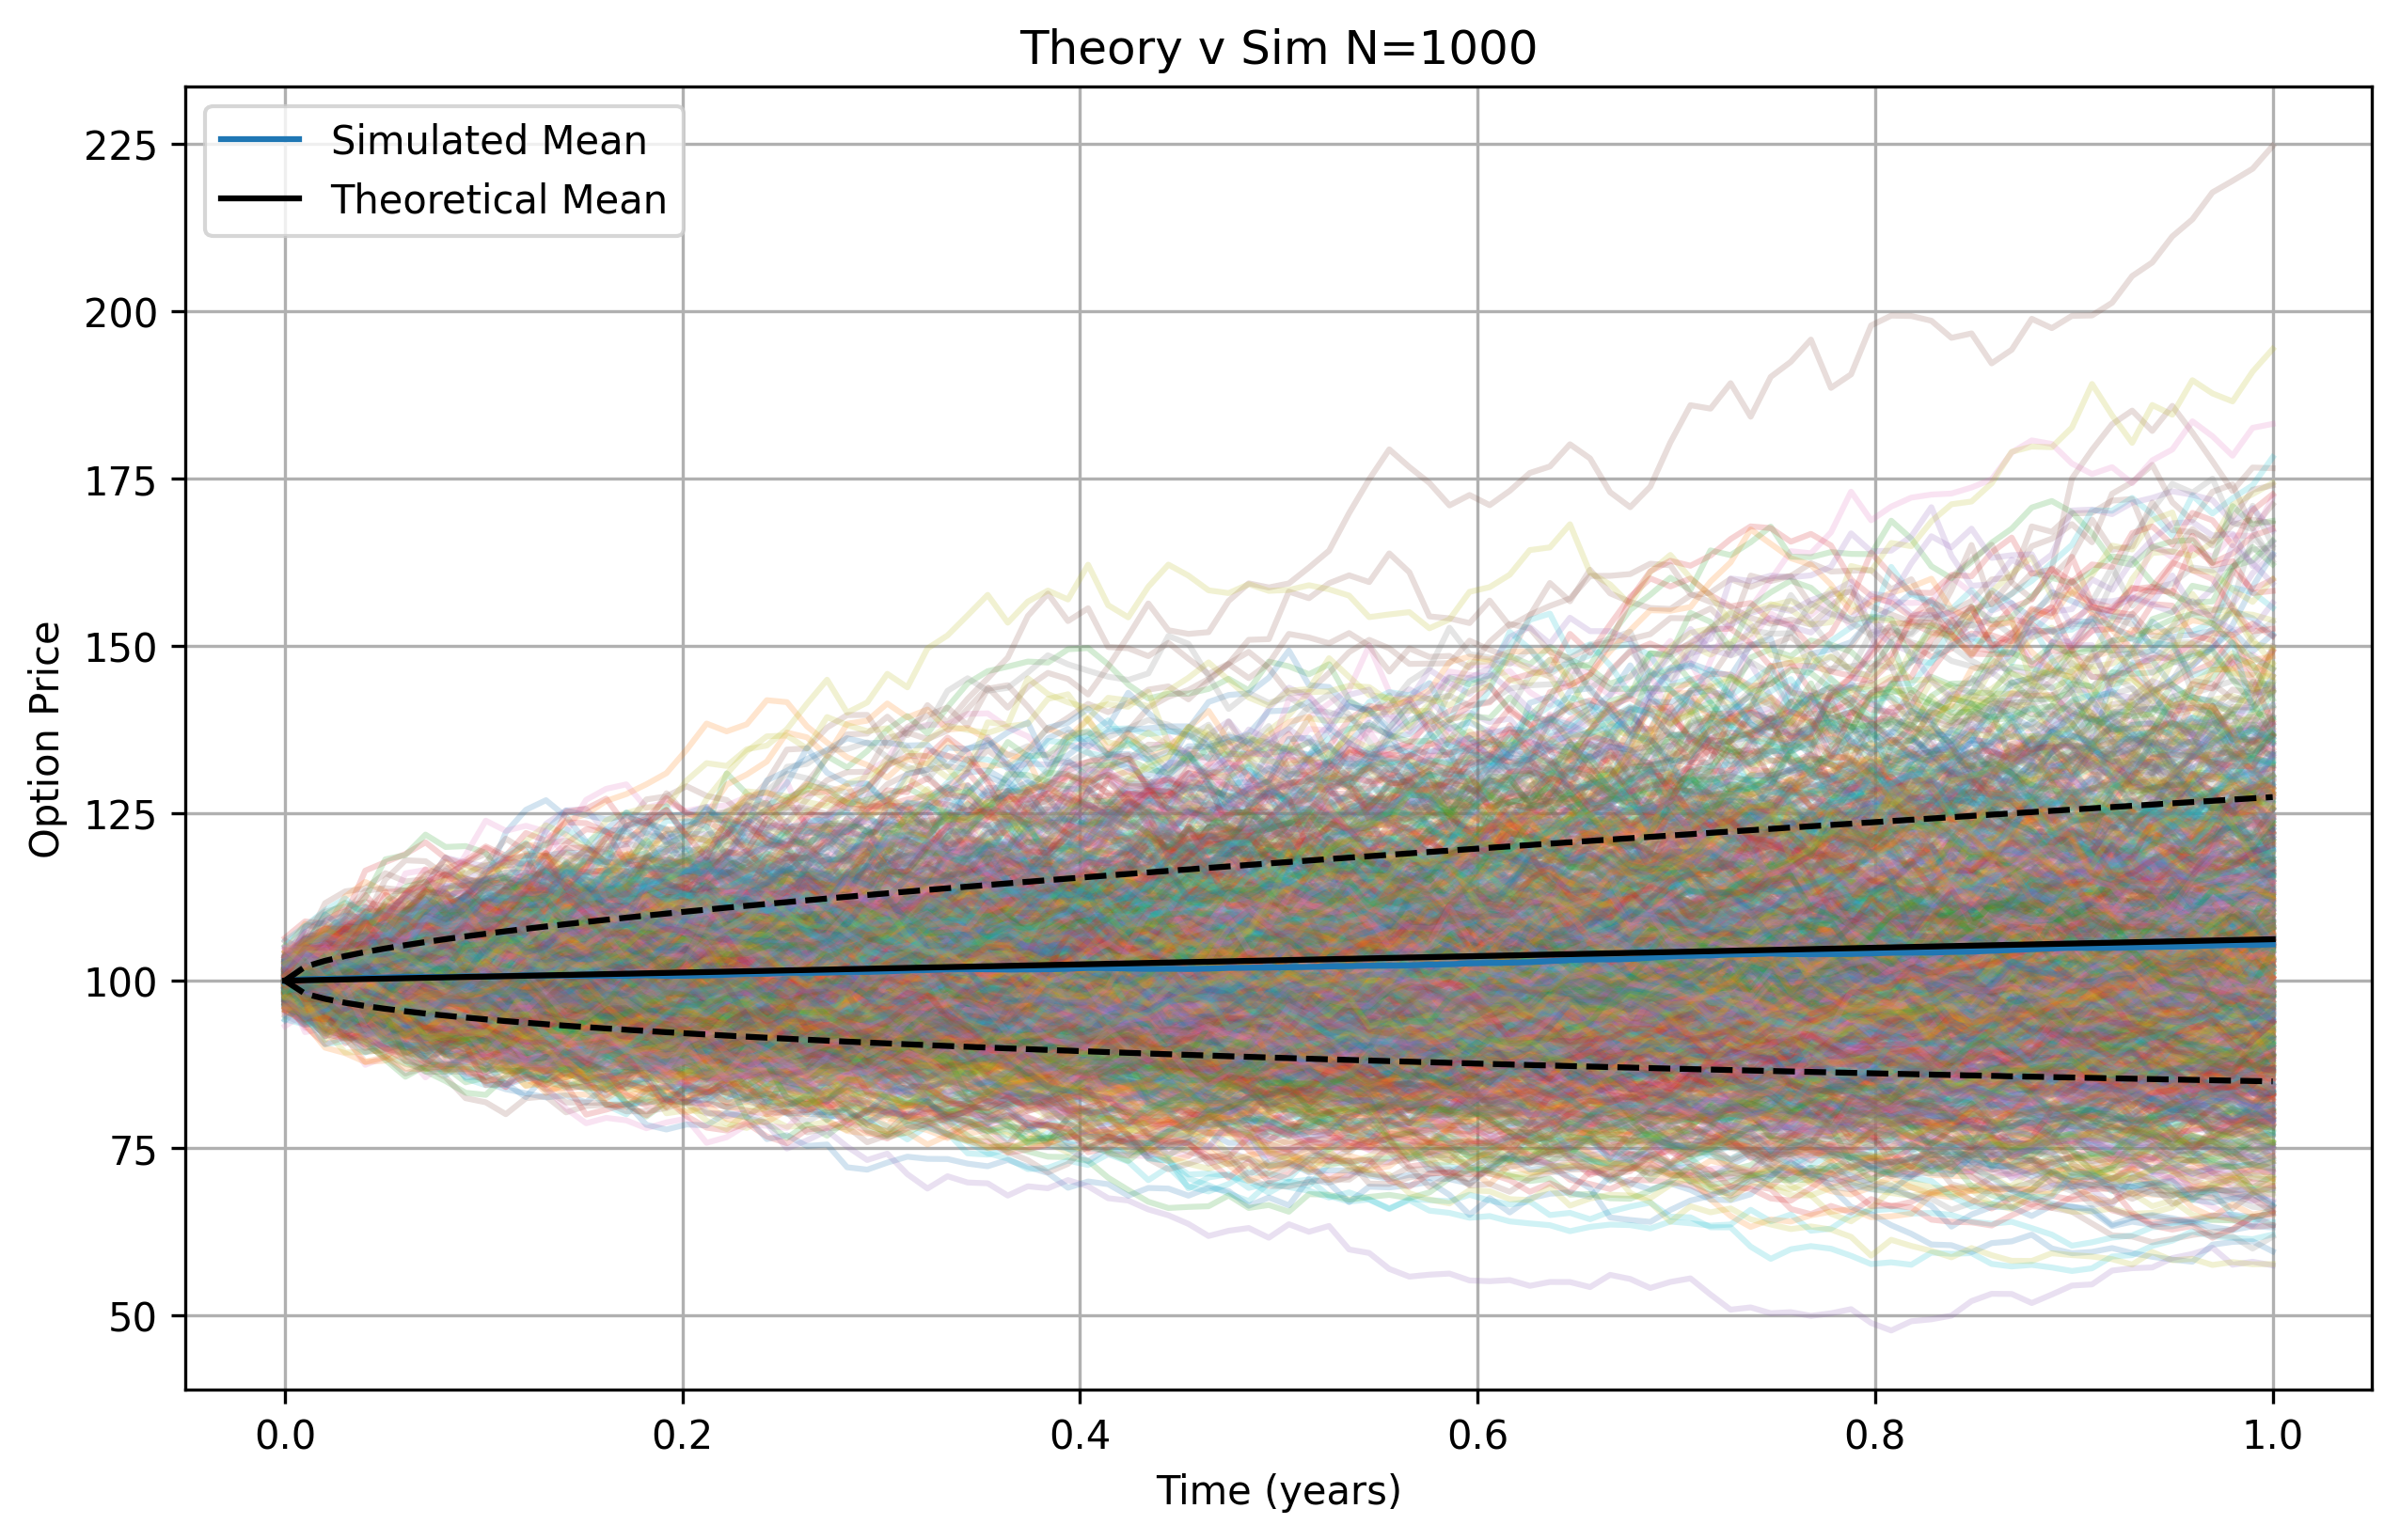

In [127]:
validate_option_step()

In [128]:
def norm_cdf_fast(x):
    return 0.5 * (1  + erf(x / np.sqrt(2)))

def bs_delta_price_call(S, K, tau, r, sigma):
    """Calculates price and delta of a European call option using the Black-Scholes formula.
    At time to maturity tau <= 0, the option is worth its intrinsic value max(S-K, 0) and has delta 1 if S > K and 0 otherwise.
    """
    if tau <= 0:
        payoff = max(S-K, 0)
        delta = 1.0 if S > K else 0.0
        return payoff, delta
    vol = sigma * np.sqrt(tau)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    d2 = d1 - vol
    nd1 = norm_cdf_fast(d1)
    nd2 = norm_cdf_fast(d2)
    price = S*nd1 - K*np.exp(-r*tau)*nd2
    delta = nd1
    return price, delta

def simulate_hedge(K, r, sigma_model, sigma_stock, T, S0=100, hedge_step=1, its=1000):
    """Simulates the hedging of a short call option over multiple paths and plots the results"""
    dt = 1/262
    N = int(T/dt)
    rng = np.random.default_rng(seed=42)

    pnl_paths = np.zeros(its)

    for i in range(its):
        S = S0

        # t = 0
        option_price, delta = bs_delta_price_call(S, K, T, r, sigma_model)
        cash = option_price - delta * S  # Initial cash from selling the option and buying the delta hedge

        for t in range(N):
            # one step stock
            S = option_step(S, r, sigma_stock, dt, rng)

            # interest on cash
            cash *= np.exp(r*dt)

            # rebalance hedge at hedge_step intervals
            if (t+1) % hedge_step == 0 or t == N-1:
                tau = max(T - (t+1)*dt, 0.0)
                option_price, new_delta = bs_delta_price_call(S, K, tau, r, sigma_model)
                # Rebalance the hedge
                cash -= (new_delta - delta) * S  # Adjust cash for the change in delta
                delta = new_delta

        # Payoff of option at maturity
        payoff = max(S-K, 0) 
        # selling the option at maturity and closing the hedge position
        pnl_paths[i] = cash - payoff + delta * S

    return pnl_paths

def plot_pnl_distribution(pnl_paths, its, hedge_step):
    """Plots the distribution of P&L from the hedging simulation"""
    plt.figure(figsize=(10, 6), dpi=300)
    plt.hist(pnl_paths, bins=50, density=True, alpha=0.6, color='g')
    plt.title(f'P&L Distribution of Short Call Hedge (N={its}, Hedge Step={hedge_step} days)')
    plt.xlabel('P&L')
    plt.ylabel('Density')
    plt.grid()

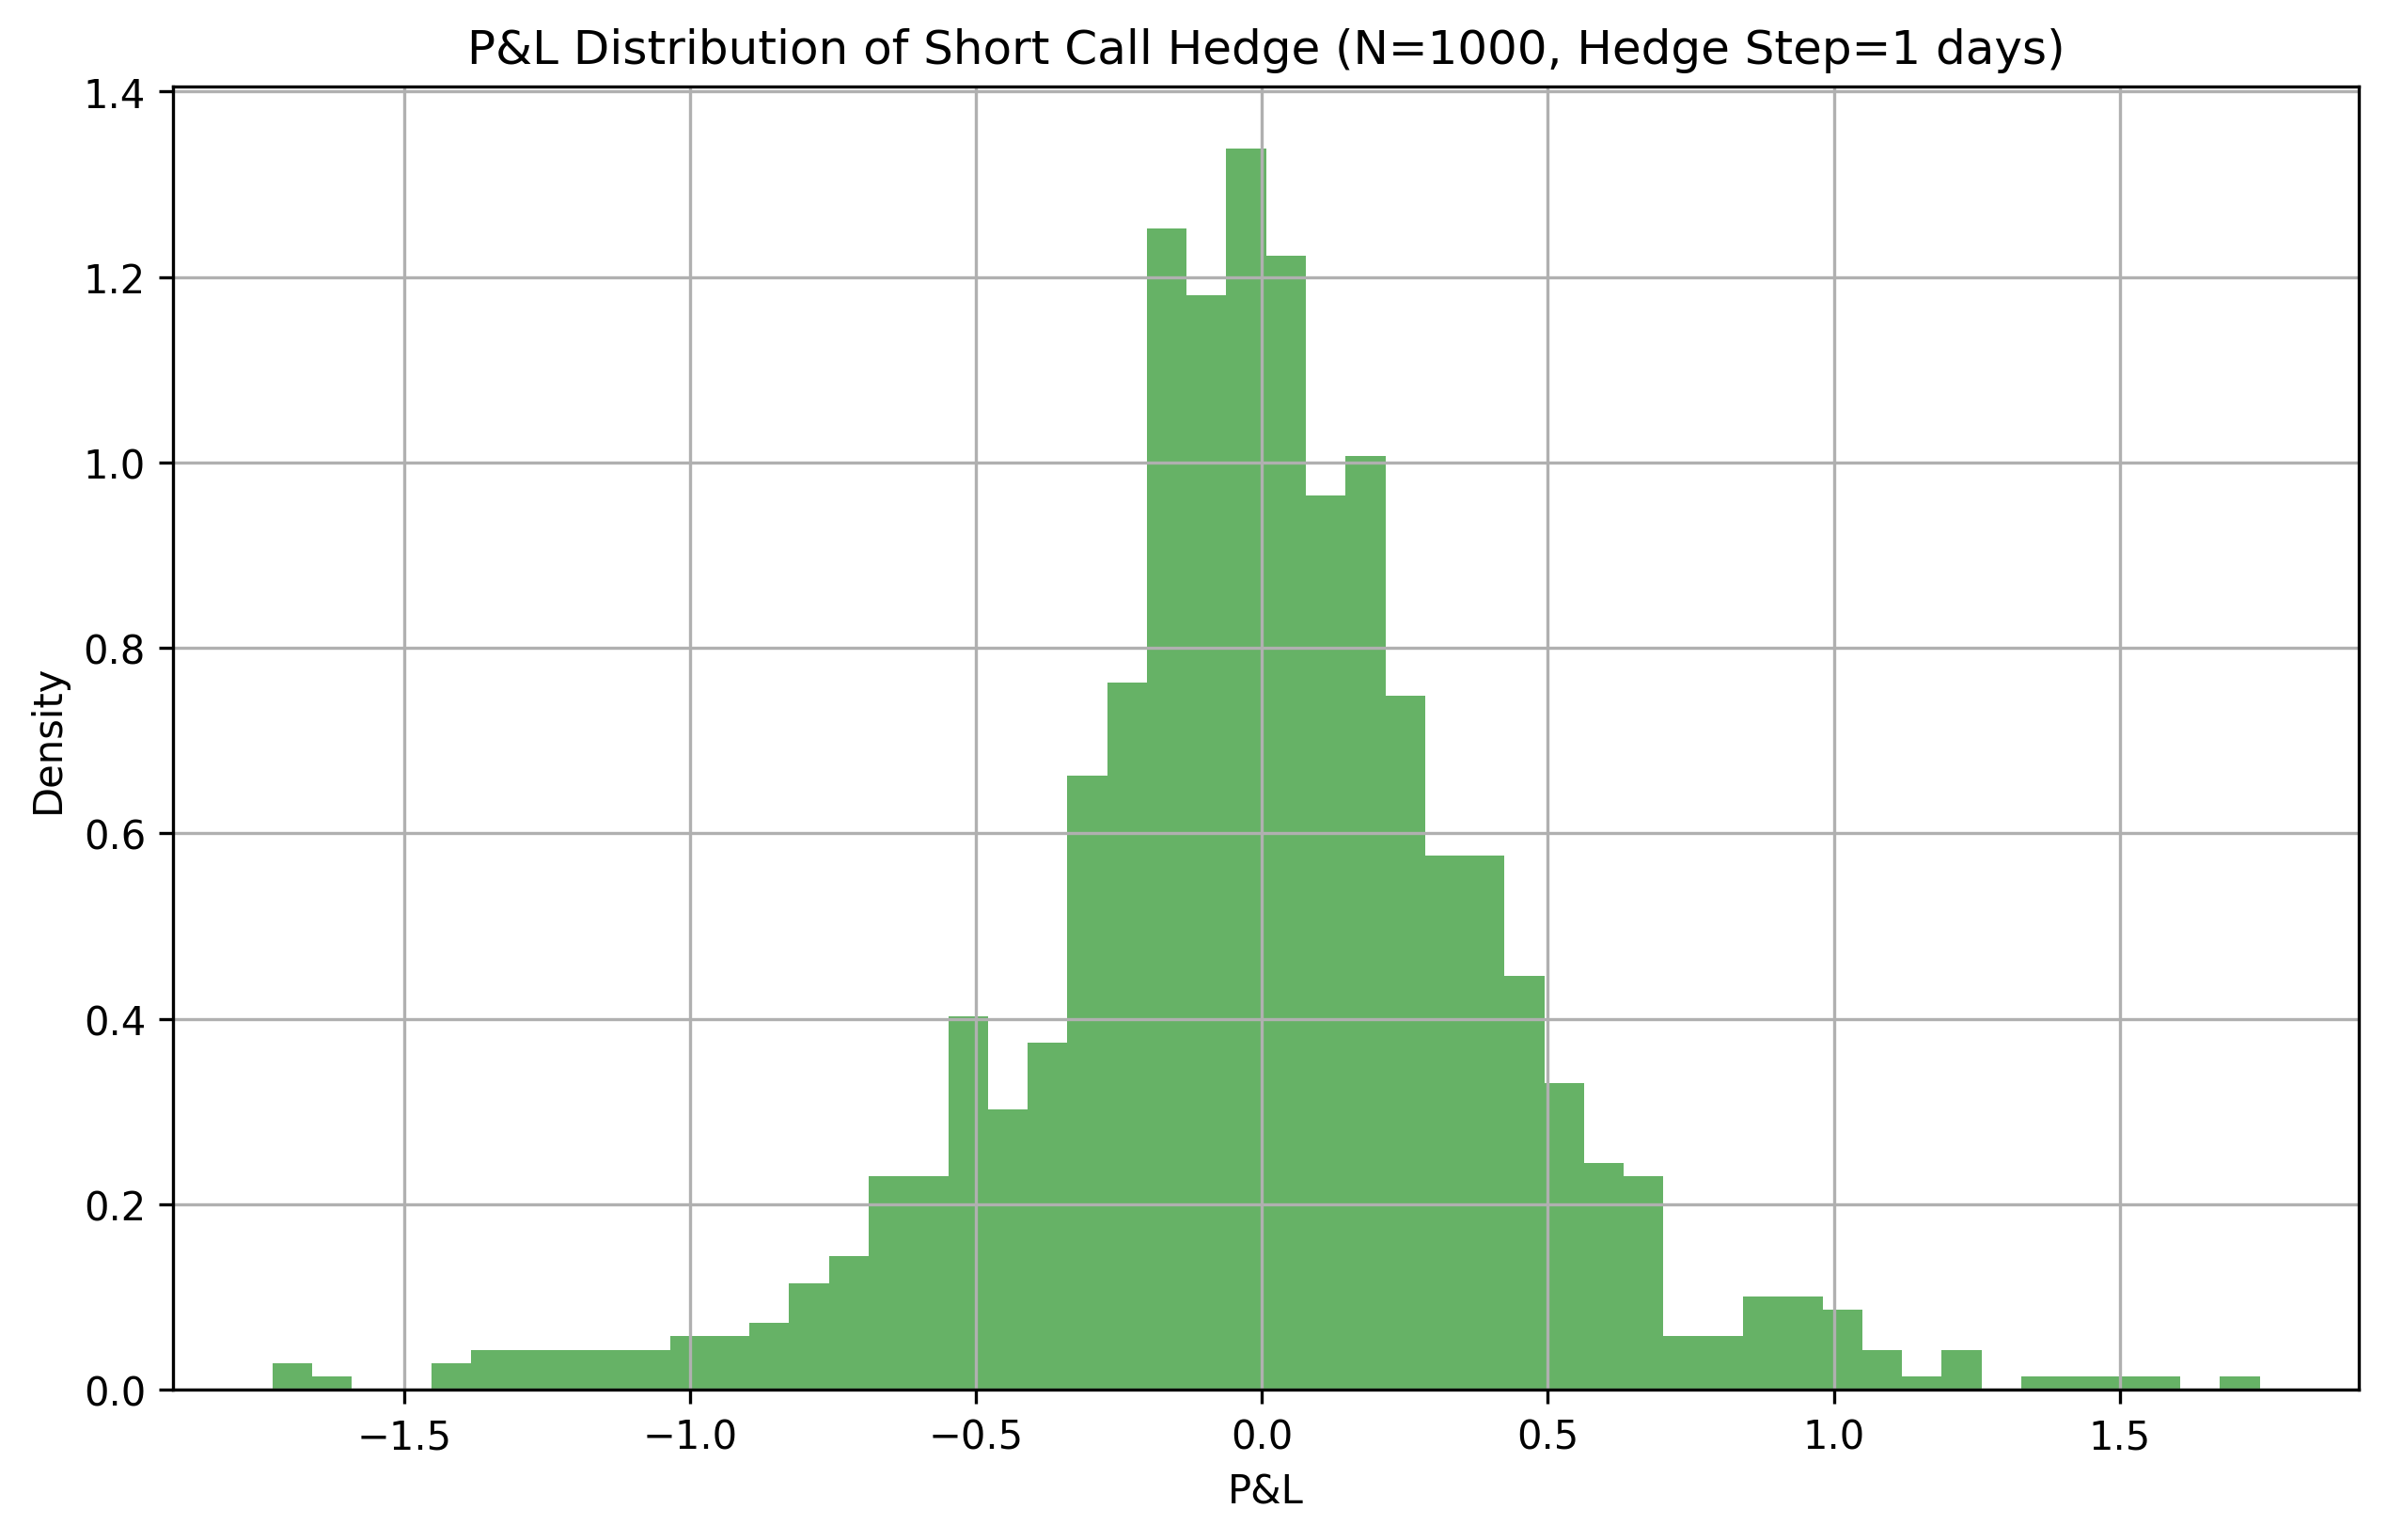

In [129]:
h1 = simulate_hedge(K=99, r=0.06, sigma_model=0.2, sigma_stock=0.2, T=1, S0=100, hedge_step=1)
plot_pnl_distribution(h1, its=1000, hedge_step=1)

P&L distribution for initial given values of the short hedge. Assumed volatilities are equal for model and stock. Hedge balance every single day.

In [130]:
hedge_steps = [_ for _ in range(1, 25)]
pnl_means = []
pnl_stds = []

for hedge_step in hedge_steps:
    pnl_paths = simulate_hedge(K=99, r=0.06, sigma_model=0.2, sigma_stock=0.2, T=1, S0=100, hedge_step=hedge_step)
    pnl_means.append(pnl_paths.mean())
    pnl_stds.append(pnl_paths.std())

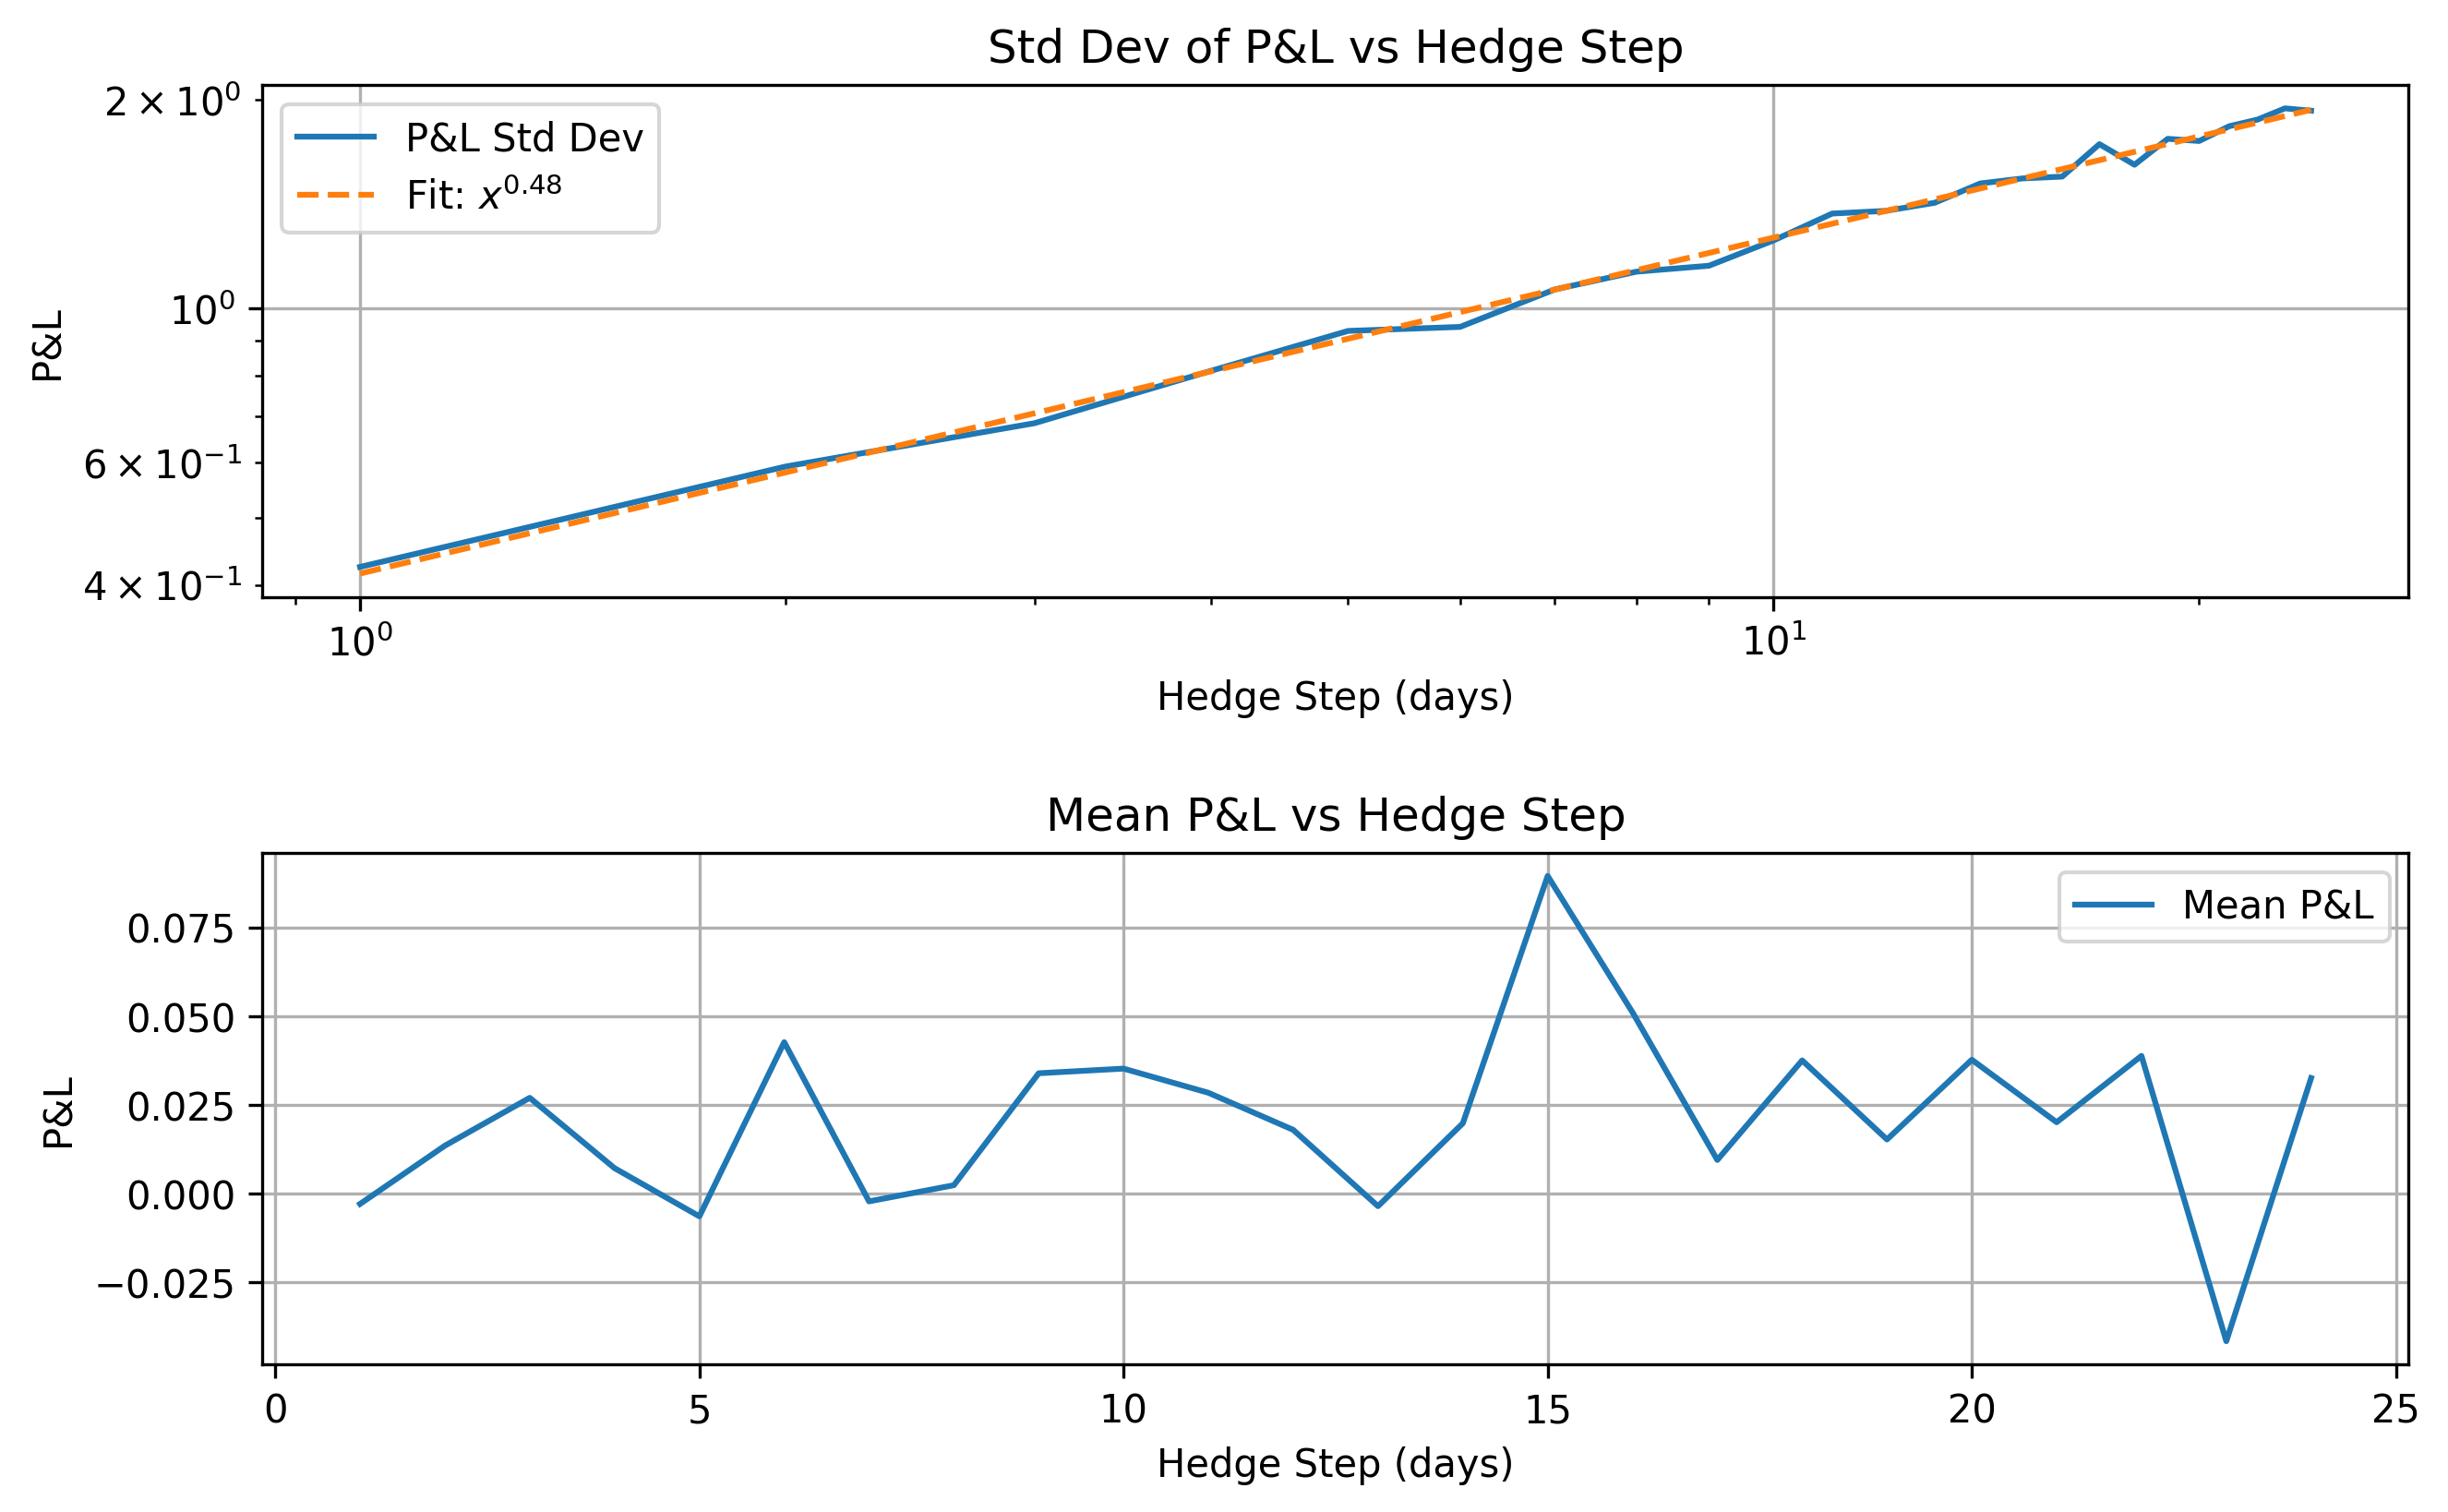

In [131]:
fig = plt.figure(figsize=(10, 6), dpi=300)
gs = fig.add_gridspec(2, 1, hspace=0.5)
axs1 = plt.subplot(gs[0])
axs2 = plt.subplot(gs[1])

coef = np.polyfit(np.log(hedge_steps), np.log(pnl_stds), 1)
slope = coef[0]
axs1.loglog(hedge_steps, pnl_stds, label='P&L Std Dev')
axs1.loglog(hedge_steps, np.exp(coef[1]) * np.array(hedge_steps)**coef[0], label=rf'Fit: $x^{{{slope:.2f}}}$', ls='--') 
axs1.set_title('Std Dev of P&L vs Hedge Step')
axs1.set_xlabel('Hedge Step (days)')
axs1.set_ylabel('P&L')
axs1.legend()
axs1.grid()

axs2.plot(hedge_steps, pnl_means, label='Mean P&L')
axs2.set_title('Mean P&L vs Hedge Step')
axs2.set_xlabel('Hedge Step (days)')
axs2.set_ylabel('P&L')
axs2.legend()
axs2.grid()

Recall that the second-order term of Ito's lemma suggests a an error per step of 

$$
\text{error per step}\approx\tfrac{1}{2}\Gamma \left( (dS)^2 - \sigma^2 S^2 dt \right)
$$

where $dt$ is the period of hedge adjustments. With 
$$
dS = \sigma S \sqrt{dt}Z
$$

we obtain a proportionality of

$$
\propto \sigma^2S^2dt(Z^2-1)
$$

and since $\sigma, S$ do not scale with $dt$ and the Wiener process $Z$ per definition has $dt$ independent variance, we conclude that the error per step is proportional to $dt$. The variance per step therefore is proportional to $dt^2$. For $N = T/dt$ steps, the total variance is $Var = Var(step) N$. The total standard deviation must thus be

$$
Std \propto \sqrt{var(step)N} \approx \sqrt{dt^2T/dt} \propto \sqrt{dt}
$$

which we confirm experimentally with the above plot.

## 2. Mismatched Volatility
To investigate $\sigma$ mismatches, we keep $\sigma_{stock} = 0.2$ constant and vary $\sigma_{model} \in [0.05, 0.5]$. 

In [132]:
# varying sigma: keep sigma stock fixed and vary sigma model
sigma_stock_fix = 0.2
sigma_models = np.arange(0.05, 0.5, 0.05)

pnl_means_sigma_mod = []
pnl_stds_sigma_mod = []
for sigma_model in sigma_models:
    pnl_paths = simulate_hedge(K=99, r=0.06, sigma_model=sigma_model, sigma_stock=sigma_stock_fix, T=1, S0=100, hedge_step=1)
    pnl_means_sigma_mod.append(pnl_paths.mean())
    pnl_stds_sigma_mod.append(pnl_paths.std())

In [133]:
# varying sigma: keep sigma stock fixed and vary sigma model
sigma_model_fix = 0.2
sigma_stocks = np.arange(0.05, 0.5, 0.05)

pnl_means_sigma_stock = []
pnl_stds_sigma_stock = []
for sigma_stock in sigma_stocks:
    pnl_paths = simulate_hedge(K=99, r=0.06, sigma_model=sigma_model_fix, sigma_stock=sigma_stock, T=1, S0=100, hedge_step=1)
    pnl_means_sigma_stock.append(pnl_paths.mean())
    pnl_stds_sigma_stock.append(pnl_paths.std())

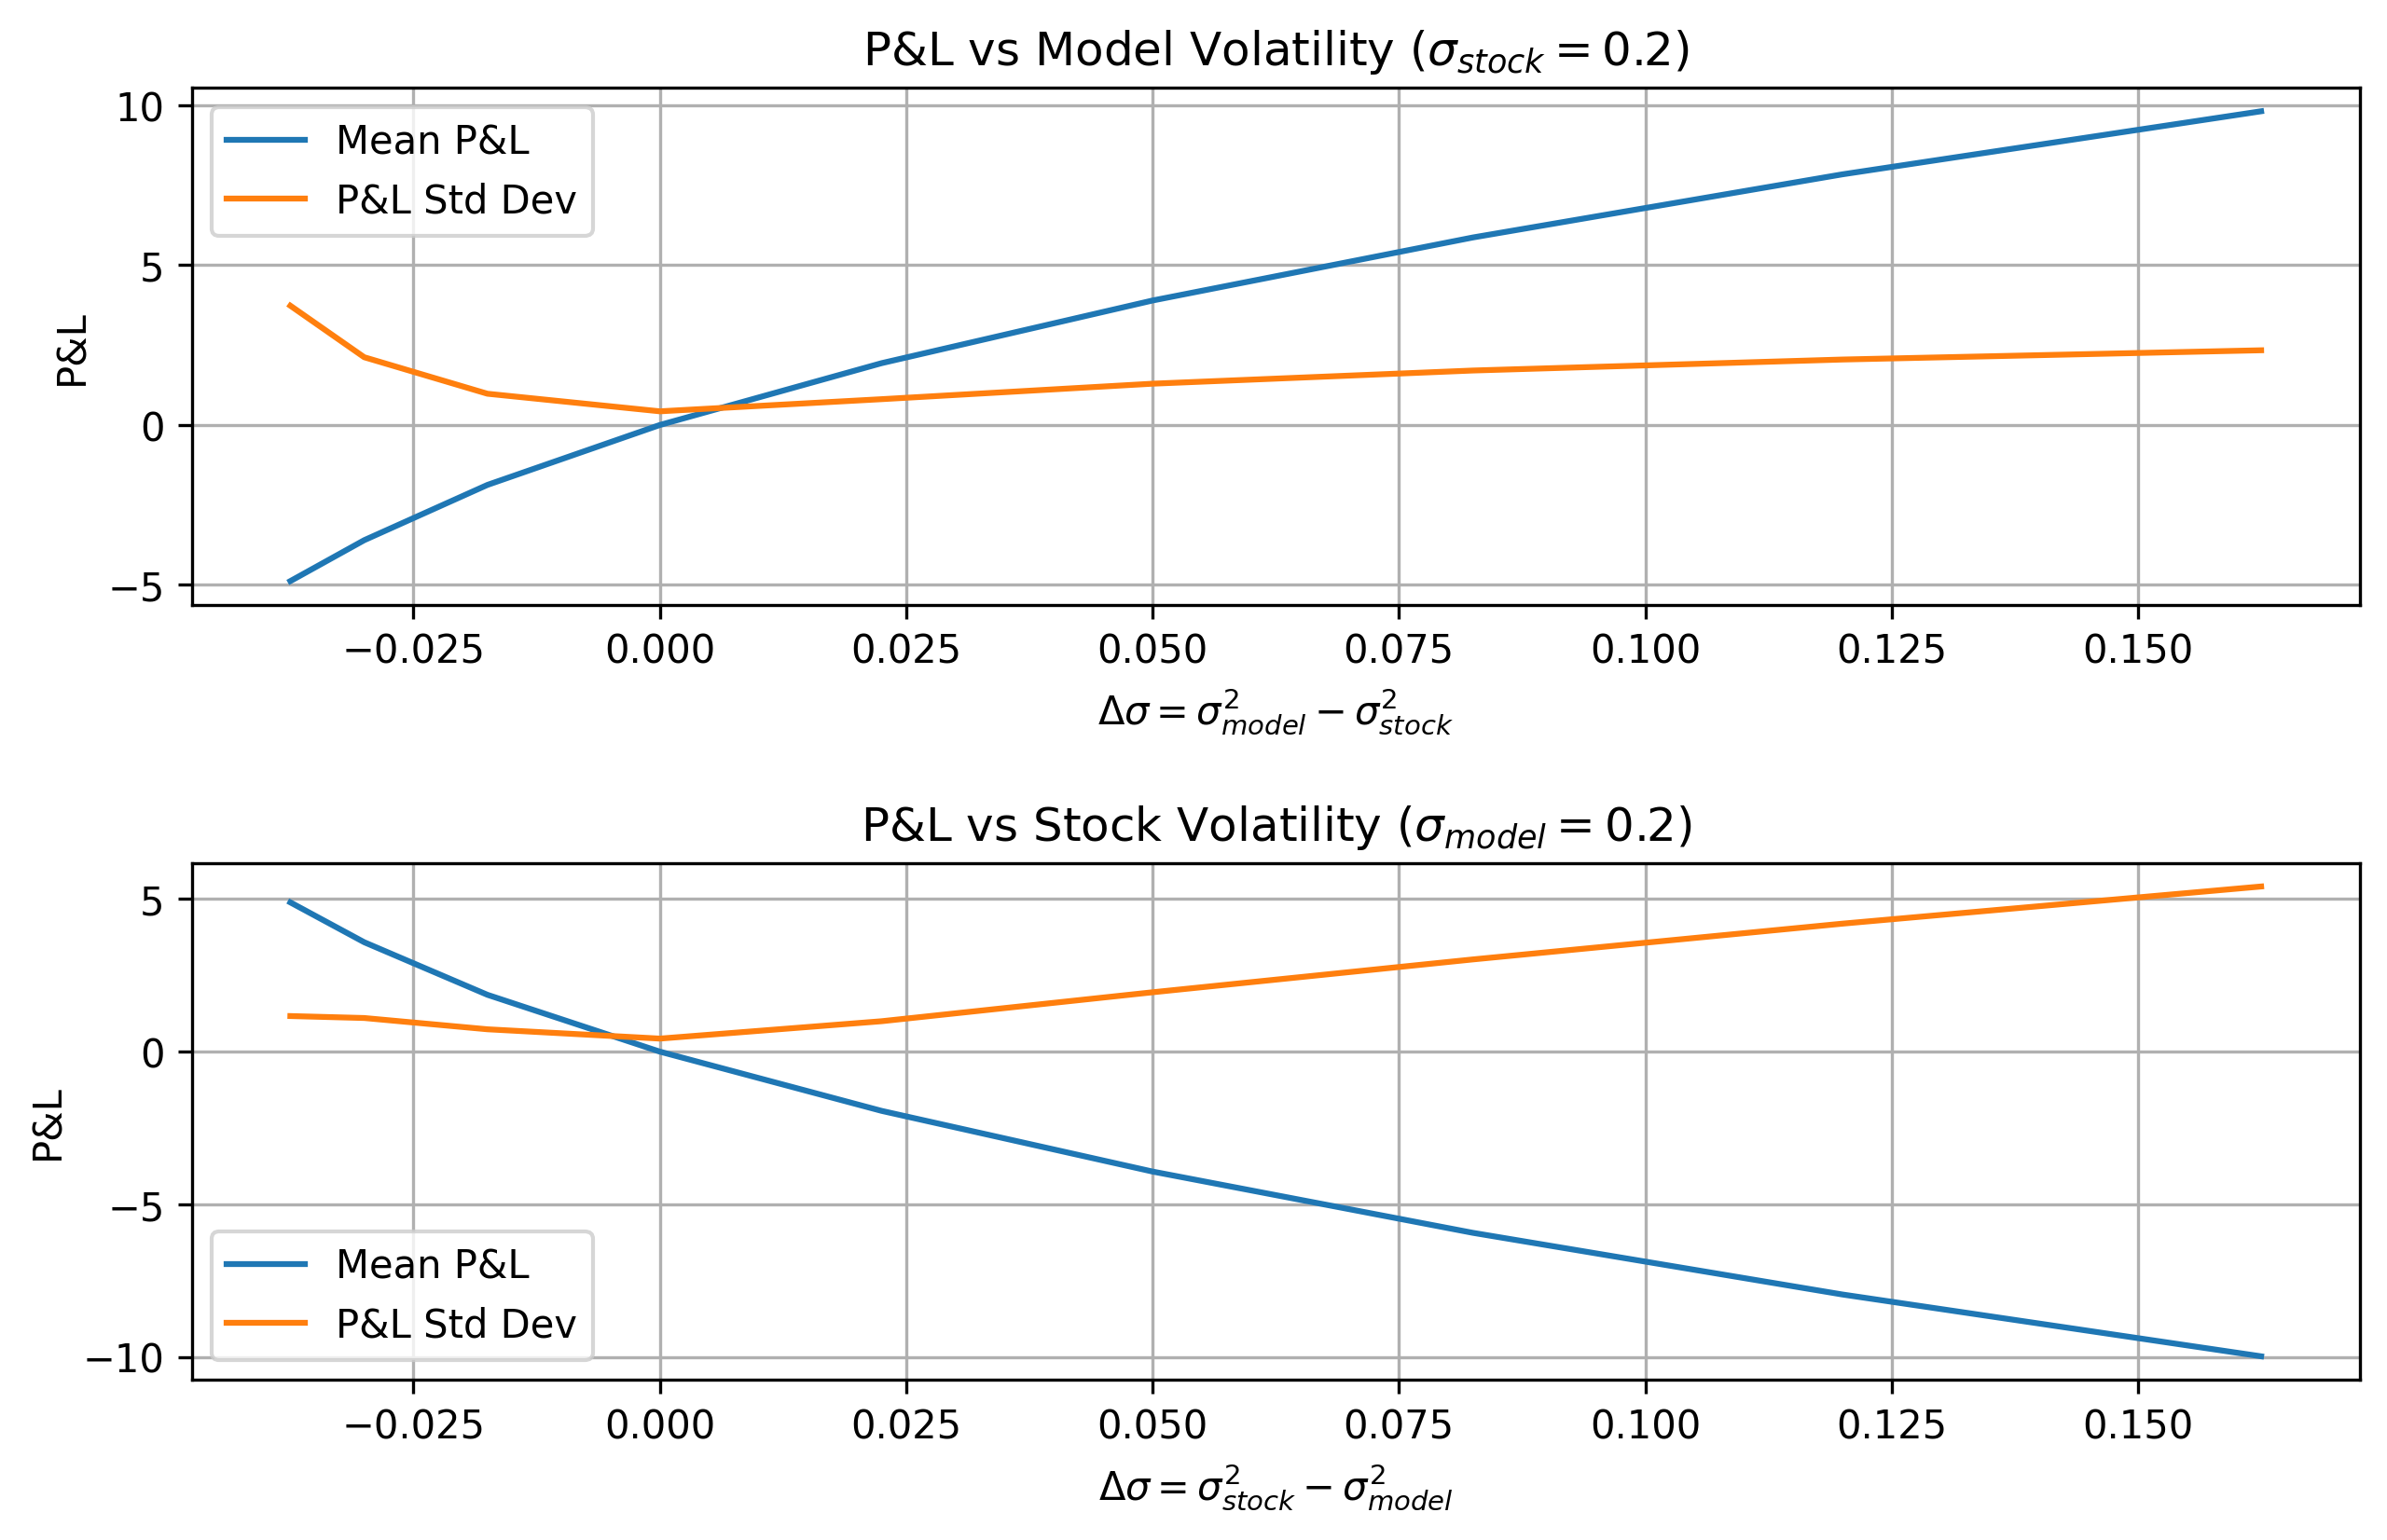

In [134]:
# plot vs sigma_model - sigma_stock fixed

sigma_diffs_mod= sigma_models**2 - sigma_stock_fix**2
sigm_diffs_stock = sigma_stocks**2 - sigma_model_fix**2

fig = plt.figure(figsize=(10, 6), dpi=300)
gs = fig.add_gridspec(2, 1, hspace=0.5)
axs1 = plt.subplot(gs[0])
axs2 = plt.subplot(gs[1])

axs1.plot(sigma_diffs_mod, pnl_means_sigma_mod, label='Mean P&L')
axs1.plot(sigma_diffs_mod, pnl_stds_sigma_mod, label='P&L Std Dev')
axs1.set_title(r'P&L vs Model Volatility ($\sigma_{stock} = 0.2$)')
axs1.set_xlabel(r'$\Delta \sigma = \sigma_{model}^2 - \sigma_{stock}^2$')
axs1.set_ylabel('P&L')
axs1.legend()
axs1.grid()

axs2.plot(sigm_diffs_stock, pnl_means_sigma_stock, label='Mean P&L')
axs2.plot(sigm_diffs_stock, pnl_stds_sigma_stock, label='P&L Std Dev')
axs2.set_title(r'P&L vs Stock Volatility ($\sigma_{model} = 0.2$)')
axs2.set_xlabel(r'$\Delta \sigma = \sigma_{stock}^2 - \sigma_{model}^2$')
axs2.set_ylabel('P&L')
axs2.legend() 
axs2.grid()

When the model volatility matches the true stock volatility, i.e.  $\sigma_{\text{model}} = \sigma_{\text{stock}}$, the delta-hedging strategy is unbiased: the mean P\&L remains approximately zero across hedge frequencies as shown in the above experiments. 

Under volatility mismatch, $\sigma_{\text{model}} \neq \sigma_{\text{stock}}$, a systematic bias emerges. If $\sigma_{\text{model}} > \sigma_{\text{stock}}$, the short call position generates a positive average P\&L, as the option was priced using an implied volatility exceeding realized volatility. Conversely, if $\sigma_{\text{model}} < \sigma_{\text{stock}}$, the strategy produces a negative average P\&L. The variance of P\&L is minimized near $\sigma_{\text{model}} = \sigma_{\text{stock}}$ and increases as $|\sigma_{\text{model}} - \sigma_{\text{stock}}|$ grows. Note that the variance grows more quickly when underestimating volatility as the hedge systematically is too small whereas on the upside, we over-hedge the position as $\Gamma$ losses are smaller than priced in.

The simulations confirm the theoretical predictions: discrete hedging introduces replication error with $\mathrm{Std} \propto \sqrt{\Delta t}$, and volatility misspecification leads to systematic gains or losses proportional to $\sigma_{\text{model}}^2 - \sigma_{\text{stock}}^2$.

Note that the bias depends on the difference $\sigma_{\text{model}}^2 - \sigma_{\text{stock}}^2$. Varying either $\sigma_{\text{model}}$ or $\sigma_{\text{stock}}$ produces equivalent results up to a sign change, since 

$$
\sigma_{\text{stock}}^2 - \sigma_{\text{model}}^2 = -\left(\sigma_{\text{model}}^2 - \sigma_{\text{stock}}^2\right)
$$ 

Thus, the mean P\&L is antisymmetric in the volatility difference, while the variance depends primarily on its magnitude.


## 3. Pricing and Hedging with Implied Volatility

Via equation (5), we obtain

$$
dS_t = rS_tdt + \sigma_t S_t dW_t^\mathbf{P} \tag{A}
$$

and apply Itô's Formula to $C_t$

$$
dC_t = \left(\frac{\partial C_t}{\partial t} + r S_t\frac{\partial C_t}{\partial S_t} + \frac{\sigma_t^2S_t^2}{2}\frac{\partial^2 C_t}{\partial S_t^2}\right)dt + \sigma_t S_t\frac{\partial C_t}{\partial S_t}dW_t^{\mathbf{P}} \tag{B}
$$

The change in delta-hedged portfolio value (P&L) for a long position is given by

$$
d\Pi_t = dC_t - \Delta_t dS_t
$$

by substituting $(B)$ and $\Delta_t = \frac{\partial C_t}{\partial S_t}$, we obtain
#

$$
d\Pi_t = \left(\frac{\partial C_t}{\partial t} + rS_t \frac{\partial C_t}{\partial S_t} + \frac{\sigma_t^2S_t^2}{2}\frac{\partial^2 C_t}{\partial S_t^2}\right)dt + \sigma_t S_t\frac{\partial C_t}{\partial S_t}dW_t^{\mathbf{P}}  - \frac{\partial C_t}{\partial S_t} dS_t
$$

We substitute $(A)$ and obtain

$$\begin{align*}
d\Pi_t &= \left(\frac{\partial C_t}{\partial t} + r S_t\frac{\partial C_t}{\partial S_t} + \frac{\sigma_t^2S_t^2}{2}\frac{\partial^2 C_t}{\partial S_t^2}\right)dt + \sigma_t S_t\frac{\partial C_t}{\partial S_t}dW_t^{\mathbf{P}}  - \frac{\partial C_t}{\partial S_t} (rS_tdt + \sigma_t S_t dW_t^\mathbf{P}) \\
&= \left(\frac{\partial C_t}{\partial t}  + \frac{\sigma_t^2S_t^2}{2}\frac{\partial^2 C_t}{\partial S_t^2} \right)dt \tag{C}
\end{align*}
$$

We arrange (4) for

$$
\frac{\partial C_t}{\partial t} = rC_t - rS_t\frac{\partial C_t}{\partial S_t}  - \frac{1}{2}\sigma_{\text{imp}}^2 S_t^2 \frac{\partial^2 C_t}{\partial S_t^2}
$$

and substitue this expression and $\Pi_t = C_t - S_tC_S$ in (C)

$$
\begin{align*}
d\Pi_t
&= \left(rC_t - rS_t\frac{\partial C_t}{\partial S_t}  - \frac{1}{2}\sigma_{\text{imp}}^2 S_t^2 \frac{\partial^2 C_t}{\partial S_t^2}  + \frac{\sigma_t^2S_t^2}{2}\frac{\partial^2 C_t}{\partial S_t^2} \right)dt \\
&= \left(r\Pi_t + \frac{\sigma_t^2 - \sigma_{\text{imp}}^2}{2}S_t^2\frac{\partial^2 C_t}{\partial S_t^2}\right)dt
\tag{D}
\end{align*}
$$

Let $X_t$ be the discounted delta-hedged portfolio value

$$
X_t = e^{-rt}\Pi_t
$$

and thus

$$
dX_t = e^{-rt}(d\Pi_t - r\Pi_tdt)
$$

We now substitute (D) and obtain the change in discounted P&L

$$
\begin{align*}
dX_t 
&= e^{-rt}\left(r\Pi_t + \frac{\sigma_t^2 - \sigma_{\text{imp}}^2}{2}S_t^2\frac{\partial^2 C_t}{\partial S_t^2} - r\Pi_t\right)dt \\
&= e^{-rt}\frac{\sigma_t^2 - \sigma_{\text{imp}}^2}{2}S_t^2\frac{\partial^2 C_t}{\partial S_t^2}dt \tag{E}
\end{align*}
$$

To obtain the value of the discounted P&L $X_T - X_0$ after $T$ we integrate

$$
X_T - X_0 = \int_0^T e^{-rt}\frac{\sigma_t^2 - \sigma_{\text{imp}}^2}{2}S_t^2\frac{\partial^2 C_t}{\partial S_t^2}dt
$$

We require the expectation value of the final P&L to be zero, so

$$
\mathbf{E} \left[X_T - X_0 \right] = 0
$$

and thus
$$
\mathbf{E} \left[\int_0^T e^{-rt}\frac{1}{2}S_t^2\frac{\partial^2 C_t}{\partial S_t^2}\left(\sigma_t^2 - \sigma_{\text{imp}}^2\right)dt\right] = 0
$$

Note that this is the expectation value for a long position and the signs of the $\sigma$ terms differ from equation (6) given in the problem set. (6) corresponds to the P&L value of a short position
 
$$
\tilde{\Pi}_t = -C_t + \Delta_t S_t = -\Pi_t
$$

while we assume a long position. Multiplying our result by $(-1)$, we arrive at equation (6).